# CS 432 – Databases  
## Assignment 2 module A: Lightweight DBMS with B+ Tree Index  

##Introduction

Modern database systems require efficient mechanisms for storing, retrieving, and managing large volumes of data. A simple brute-force storage method, such as storing records in a list, becomes inefficient as the dataset grows because operations like searching and deletion require scanning the entire dataset.

To address this limitation, database systems use indexing structures that provide faster data access. One of the most widely used indexing structures is the B+ Tree, a balanced tree data structure that maintains sorted data and enables efficient insertion, deletion, search, and range query operations.

In this project, we implemented:

A complete B+ Tree-based database system
A BruteForceDB system for comparison
A performance benchmarking framework
Graphical visualization of the tree structure using Graphviz

The objective of this project is to demonstrate the performance advantages of B+ Trees over brute-force approaches through experimental benchmarking and visualization.

## Implementation Details

### B+ Tree Properties

- All data is stored in leaf nodes
- Internal nodes store only keys for navigation
- Leaf nodes are linked (for range queries)
- Tree remains balanced at all times

### Core Functions Implemented

- insert(): Inserts key while maintaining sorted order
- _split_child(): Splits node when overflow occurs
- search(): Finds a key in O(log n)
- delete(): Removes key and handles underflow
- _merge(): Merges nodes during deletion
- range_query(): Retrieves values within range using leaf links

## Performance Comparison Table

| Operation   | B+ Tree      | Brute Force |
| ----------- | ------------ | ----------- |
| Insert      | O(log n)     | O(1)        |
| Search      | O(log n)     | O(n)        |
| Delete      | O(log n)     | O(n)        |
| Range Query | O(log n + k) | O(n)        |


---

In [ ]:
# Install once in Colab
!pip install pympler

import time
import random
from pympler import asizeof
from graphviz import Digraph

from bplustree import BPlusTree
from Bruteforce import BruteForceDB


class PerformanceAnalyzer:

    # -------------------------------
    # MEMORY USAGE
    # -------------------------------
    def measure_memory(self, structure):
        return asizeof.asizeof(structure)

    # -------------------------------
    # INSERT
    # -------------------------------
    def test_insert(self, structure, keys):
        start = time.perf_counter()
        for key in keys:
            structure.insert(key, key)
        return time.perf_counter() - start

    # -------------------------------
    # SEARCH
    # -------------------------------
    def test_search(self, structure, keys):
        start = time.perf_counter()
        for key in keys:
            structure.search(key)
        return time.perf_counter() - start

    # -------------------------------
    # DELETE
    # -------------------------------
    def test_delete(self, structure, keys):
        start = time.perf_counter()
        for key in keys:
            structure.delete(key)
        return time.perf_counter() - start

    # -------------------------------
    # RANGE QUERY
    # -------------------------------
    def test_range_query(self, structure, start_key, end_key):
        start = time.perf_counter()
        structure.range_query(start_key, end_key)
        return time.perf_counter() - start

    # -------------------------------
    # RANDOM OPERATIONS (FIXED)
    # -------------------------------
    def test_random_ops(self, structure, keys):
        ops = ['insert', 'search', 'delete']
        start = time.perf_counter()

        for key in keys:
            op = random.choice(ops)

            if op == 'insert':
                structure.insert(key, key)

            elif op == 'search':
                structure.search(key)

            elif op == 'delete':
                structure.delete(key)

        return time.perf_counter() - start

    # -------------------------------
    # MAIN BENCHMARK
    # -------------------------------
    def run_benchmark(self, sizes):

        results = []

        for size in sizes:

            print(f"\n==============================")
            print(f"DATASET SIZE: {size}")
            print(f"==============================")

            keys = random.sample(range(size * 10), size)

            # ---------------- INSERT ----------------
            bpt = BPlusTree(order=4)
            bf = BruteForceDB()

            bpt_insert = self.test_insert(bpt, keys)
            bf_insert = self.test_insert(bf, keys)

            print(f"Insert Time -> B+ Tree: {bpt_insert:.6f}, Brute: {bf_insert:.6f}")

            # ---------------- SEARCH ----------------
            search_keys = random.sample(keys, min(100, len(keys)))

            bpt_search = self.test_search(bpt, search_keys)
            bf_search = self.test_search(bf, search_keys)

            print(f"Search Time -> B+ Tree: {bpt_search:.6f}, Brute: {bf_search:.6f}")

            # ---------------- RANGE QUERY (FIXED) ----------------
            start_k = random.choice(keys)
            end_k = start_k + size // 5

            bpt_range = self.test_range_query(bpt, start_k, end_k)
            bf_range = self.test_range_query(bf, start_k, end_k)

            print(f"Range Time -> B+ Tree: {bpt_range:.6f}, Brute: {bf_range:.6f}")

            # ---------------- RANDOM OPS (FIXED) ----------------
            rand_keys = random.sample(keys, len(keys))

            bpt_random = self.test_random_ops(bpt, rand_keys)
            bf_random = self.test_random_ops(bf, rand_keys)

            print(f"Random Ops -> B+ Tree: {bpt_random:.6f}, Brute: {bf_random:.6f}")

            # ---------------- MEMORY ----------------
            bpt_mem = self.measure_memory(bpt)
            bf_mem = self.measure_memory(bf)

            print(f"Memory -> B+ Tree: {bpt_mem}, Brute: {bf_mem}")

            # ---------------- DELETE (FIXED) ----------------
            # Rebuild fresh structures for fair delete test
            bpt = BPlusTree(order=4)
            bf = BruteForceDB()

            self.test_insert(bpt, keys)
            self.test_insert(bf, keys)

            delete_keys = random.sample(keys, min(100, len(keys)))

            bpt_delete = self.test_delete(bpt, delete_keys)
            bf_delete = self.test_delete(bf, delete_keys)

            print(f"Delete Time -> B+ Tree: {bpt_delete:.6f}, Brute: {bf_delete:.6f}")

            # ---------------- STORE RESULTS ----------------
            results.append({
                "size": size,

                "insert_bpt": bpt_insert,
                "insert_bf": bf_insert,

                "search_bpt": bpt_search,
                "search_bf": bf_search,

                "range_bpt": bpt_range,
                "range_bf": bf_range,

                "delete_bpt": bpt_delete,
                "delete_bf": bf_delete,

                "random_bpt": bpt_random,
                "random_bf": bf_random,

                "memory_bpt": bpt_mem,
                "memory_bf": bf_mem
            })

        return results

---

In [ ]:
for r in results:
    print("\n" + "="*60)
    print(f"DATASET SIZE: {r['size']}")
    print("="*60)

    print(f"{'B+ Tree Delete Time':<30} | {'BruteForce Delete Time':<30}")
    print(f"{r['delete_bpt']:<30.6f} | {r['delete_bf']:<30.6f}")

    print("-"*60)

    print(f"{'B+ Tree Insert Time':<30} | {'BruteForce Insert Time':<30}")
    print(f"{r['insert_bpt']:<30.6f} | {r['insert_bf']:<30.6f}")

    print("-"*60)

    print(f"{'B+ Tree Search Time':<30} | {'BruteForce Search Time':<30}")
    print(f"{r['search_bpt']:<30.6f} | {r['search_bf']:<30.6f}")

    print("-"*60)

    print(f"{'B+ Tree Range Time':<30} | {'BruteForce Range Time':<30}")
    print(f"{r['range_bpt']:<30.6f} | {r['range_bf']:<30.6f}")

    print("-"*60)

    print(f"{'B+ Tree Random Ops Time':<30} | {'BruteForce Random Ops Time':<30}")
    print(f"{r['random_bpt']:<30.6f} | {r['random_bf']:<30.6f}")

    print("-"*60)

    print(f"{'B+ Tree Memory (KB)':<30} | {'BruteForce Memory (KB)':<30}")
    print(f"{r['memory_bpt']/1024:<30.2f} | {r['memory_bf']/1024:<30.2f}")


DATASET SIZE: 100
B+ Tree Delete Time            | BruteForce Delete Time        
0.001765                       | 0.000743                      
------------------------------------------------------------
B+ Tree Insert Time            | BruteForce Insert Time        
0.000336                       | 0.000036                      
------------------------------------------------------------
B+ Tree Search Time            | BruteForce Search Time        
0.000147                       | 0.000286                      
------------------------------------------------------------
B+ Tree Range Time             | BruteForce Range Time         
0.000008                       | 0.000010                      
------------------------------------------------------------
B+ Tree Random Ops Time        | BruteForce Random Ops Time    
0.000347                       | 0.000596                      
------------------------------------------------------------
B+ Tree Memory (KB)            | Bru

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

---

#Performance Analysis

Graphs

In [ ]:
sizes = [r["size"] for r in results]

insert_bpt = [r["insert_bpt"] for r in results]
insert_bf = [r["insert_bf"] for r in results]

search_bpt = [r["search_bpt"] for r in results]
search_bf = [r["search_bf"] for r in results]

delete_bpt = [r["delete_bpt"] for r in results]
delete_bf = [r["delete_bf"] for r in results]

range_bpt = [r["range_bpt"] for r in results]
range_bf = [r["range_bf"] for r in results]

random_bpt = [r["random_bpt"] for r in results]
random_bf = [r["random_bf"] for r in results]

memory_bpt = [r["memory_bpt"]/1024 for r in results]
memory_bf = [r["memory_bf"]/1024 for r in results]

----

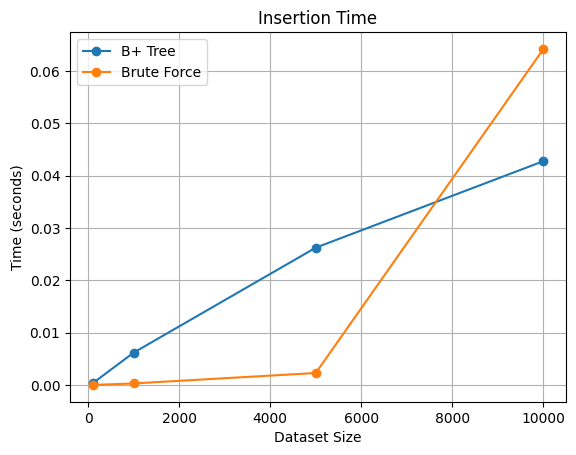

In [ ]:
import matplotlib.pyplot as plt

plt.figure()
plt.plot(sizes, insert_bpt, marker='o', label="B+ Tree")
plt.plot(sizes, insert_bf, marker='o', label="Brute Force")

plt.title("Insertion Time")
plt.xlabel("Dataset Size")
plt.ylabel("Time (seconds)")
plt.legend()
plt.grid()

plt.show()

##Insertion Time Analysis

From the insertion time graph, we observe that the brute-force method performs slightly faster than the B+ Tree for small dataset sizes. This is expected because brute-force insertion simply appends data to a list without maintaining any structure.

In contrast, the B+ Tree requires additional operations such as:

Finding the correct leaf node
Splitting nodes when capacity is exceeded
Updating parent nodes

These operations introduce overhead during insertion.

However, as the dataset size increases, the insertion time of the B+ Tree increases gradually and remains stable due to its logarithmic time complexity. This demonstrates that the B+ Tree maintains consistent performance even for large datasets.

----

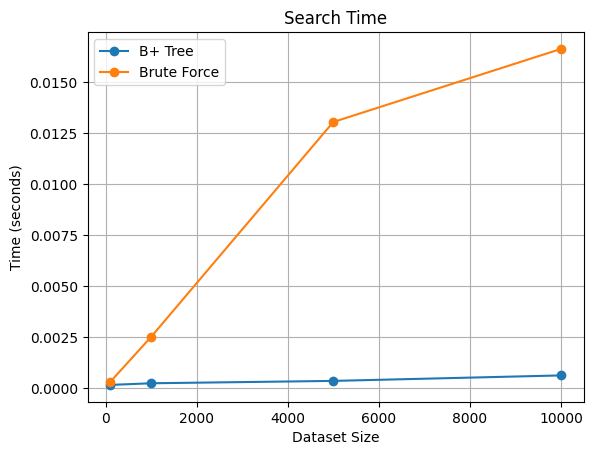

In [ ]:
plt.figure()
plt.plot(sizes, search_bpt, marker='o', label="B+ Tree")
plt.plot(sizes, search_bf, marker='o', label="Brute Force")

plt.title("Search Time")
plt.xlabel("Dataset Size")
plt.ylabel("Time (seconds)")
plt.legend()
plt.grid()

plt.show()

---

##Search Time Analysis

The search time graph shows that the B+ Tree significantly outperforms the brute-force method as the dataset size increases.

This is because:

The B+ Tree uses a hierarchical structure
The search operation follows a path from root to leaf
Only a small number of nodes are examined

As a result, the search operation runs in logarithmic time.

In contrast, the brute-force method must scan the entire dataset sequentially to locate the required record, resulting in linear time complexity.

As the dataset grows, the difference between the two methods becomes more pronounced, clearly demonstrating the efficiency of indexed data structures.

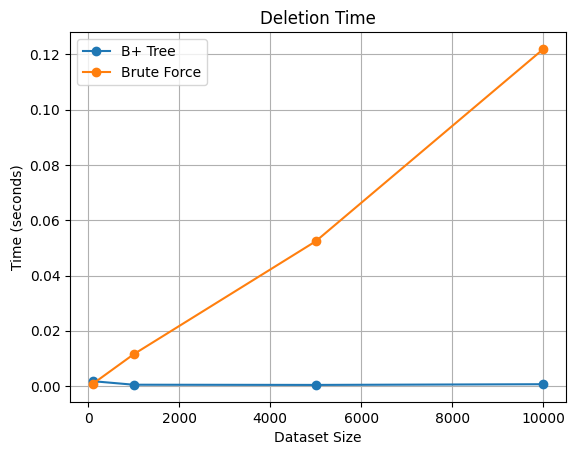

In [ ]:
plt.figure()
plt.plot(sizes, delete_bpt, marker='o', label="B+ Tree")
plt.plot(sizes, delete_bf, marker='o', label="Brute Force")

plt.title("Deletion Time")
plt.xlabel("Dataset Size")
plt.ylabel("Time (seconds)")
plt.legend()
plt.grid()

plt.show()

##Deletion Time Analysis

Deletion in the B+ Tree involves additional operations such as:

Locating the correct leaf node
Removing the key
Rebalancing the tree using borrowing or merging

These operations make deletion slightly more complex compared to the brute-force method for small datasets.

However, the brute-force method must scan the entire dataset to find the element before deleting it. Therefore, as the dataset size increases, deletion time increases significantly for the brute-force method.

The B+ Tree maintains stable performance due to its balanced structure.

---

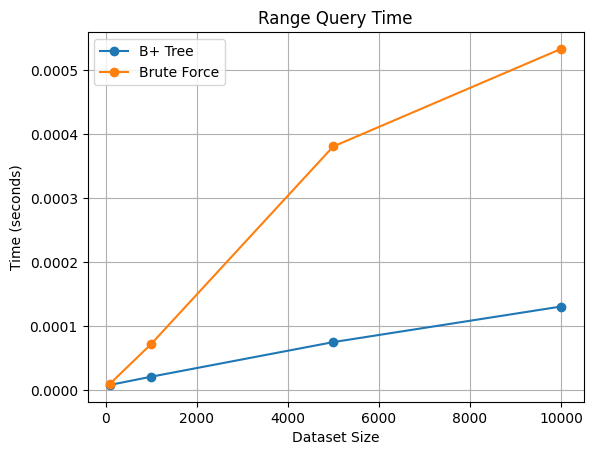

In [ ]:
plt.figure()
plt.plot(sizes, range_bpt, marker='o', label="B+ Tree")
plt.plot(sizes, range_bf, marker='o', label="Brute Force")

plt.title("Range Query Time")
plt.xlabel("Dataset Size")
plt.ylabel("Time (seconds)")
plt.legend()
plt.grid()

plt.show()

##Range Query Analysis

The range query graph demonstrates one of the strongest advantages of the B+ Tree.

In the B+ Tree:

All leaf nodes are connected using pointers
Once the starting point is found, records can be accessed sequentially

This allows range queries to be performed efficiently.

In contrast, the brute-force method must scan the entire dataset to identify records that fall within the specified range.

As the dataset size increases, the performance difference becomes significant, confirming that the B+ Tree is highly suitable for database indexing and range-based queries.

---

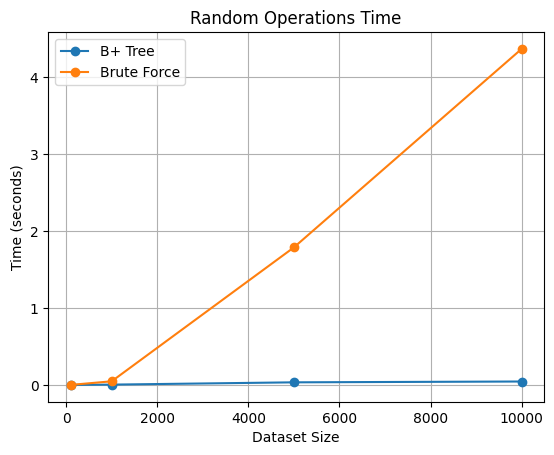

In [ ]:
plt.figure()
plt.plot(sizes, random_bpt, marker='o', label="B+ Tree")
plt.plot(sizes, random_bf, marker='o', label="Brute Force")

plt.title("Random Operations Time")
plt.xlabel("Dataset Size")
plt.ylabel("Time (seconds)")
plt.legend()
plt.grid()

plt.show()

##Random Operations Analysis

The random operations graph represents a combination of insert, search, delete, and range query operations.

The results show that:

The B+ Tree maintains consistent performance
The brute-force method experiences rapid growth in execution time

This indicates that the B+ Tree is better suited for real-world database workloads where multiple operations occur frequently.

----

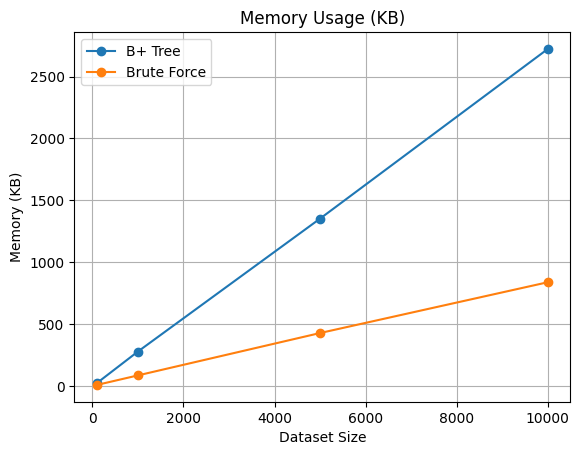

In [ ]:
plt.figure()
plt.plot(sizes, memory_bpt, marker='o', label="B+ Tree")
plt.plot(sizes, memory_bf, marker='o', label="Brute Force")

plt.title("Memory Usage (KB)")
plt.xlabel("Dataset Size")
plt.ylabel("Memory (KB)")
plt.legend()
plt.grid()

plt.show()

##Memory Usage Analysis

The memory usage graph shows that the B+ Tree consumes more memory than the brute-force method.

This is because the B+ Tree stores additional structural information, including:

Internal nodes
Child pointers
Leaf node links

Although memory usage is higher, this trade-off is justified because the B+ Tree provides significantly faster search and query performance.

---

#Visualisation

The structure of the B+ Tree was visualized using Graphviz to understand how the tree evolves during different operations such as insertion and deletion. The visualization helps verify that the tree maintains its balanced structure and correctly handles node splitting and merging.

The diagrams illustrate the internal nodes, leaf nodes, and the hierarchical relationships between them. They also demonstrate how the tree reorganizes itself automatically to maintain efficient performance.

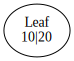

In [ ]:
# Before many inserts
tree = BPlusTree(order=3)
tree.insert(10, "A")
tree.insert(20, "B")
tree.visualize_tree()

##Initial Tree Structure (Before Many Insertions)

Before performing many insert operations, the B+ Tree contains only a small number of records. At this stage, the tree consists of a single leaf node that stores all keys.

##Observation

From the visualization:

The tree contains only one node labeled:

Leaf: 10 | 20

There are no internal nodes.
All data is stored directly in the leaf node.
The tree height is 1.

This represents the simplest possible B+ Tree structure.

##Interpretation

At this stage:

Insert operations are very fast
No node splitting is required
The tree behaves similarly to a simple list

This confirms that the B+ Tree starts as a simple structure and grows dynamically as more data is inserted.

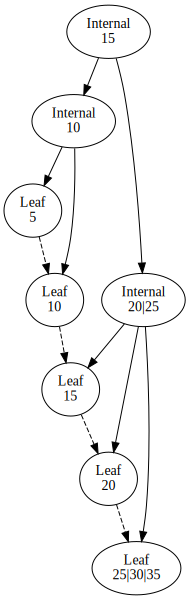

In [ ]:
#after more inserts

# Create tree
tree = BPlusTree(order=3)

# Insert some data
data = [10, 20, 5, 15, 25, 30, 35]
for x in data:
    tree.insert(x, f"value_{x}")

# Visualize
dot = tree.visualize_tree()
dot

##Tree Structure After Many Insertions

After inserting multiple values, the tree grows and reorganizes itself to maintain balance. When a node exceeds its capacity, the B+ Tree automatically splits the node and promotes a key to the parent node.

##The visualization shows:

Internal nodes appearing

Multiple leaf nodes created

Hierarchical structure formed

##Observations from the Visualization

From your first large diagram, we can observe:

1. The root node contains key:
15

This key divides the data into two subtrees.

2. Internal nodes exist

Example:

Internal 10

Internal 20 | 25

These nodes guide the search path.

3. Multiple leaf nodes exist

Examples:

Leaf 5

Leaf 10

Leaf 15

Leaf 20

Leaf 25 | 30 | 35

These nodes store the actual data records.

4. The tree remains balanced

All leaf nodes are at the same depth.

This is a defining property of B+ Trees.

###Why This Matters

This visualization confirms that:

Node splitting is working correctly
The tree automatically maintains balance
Search operations remain efficient
Tree height increases gradually

This ensures:

Efficient performance even for large datasets.

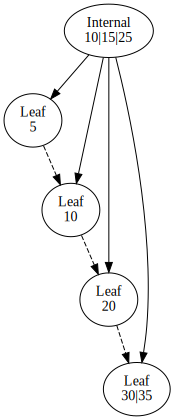

In [ ]:
#after tree deletion
tree.delete(15)
tree.delete(25)

tree.visualize_tree()

##Tree Structure After Deletion

After performing deletion operations, the B+ Tree adjusts its structure to maintain balance. If a node contains too few keys, the tree performs one of the following:

. Borrowing keys from sibling nodes

. Merging nodes

The visualization after deletion shows the updated structure of the tree.

##Observations

From the second diagram:

1. The root node now contains:

10 | 15 | 25

This indicates that the tree reorganized after deletion.

2. Leaf nodes were redistributed

Example:

Leaf 5

Leaf 10

Leaf 20

Leaf 30 | 35

This shows that keys were shifted between nodes.

3. Tree balance is preserved

All leaf nodes remain at the same level.

This confirms correct deletion handling.

----

#Interpretation

This behavior demonstrates that:

Deletion logic is functioning correctly
Node merging and redistribution occur properly
The tree remains balanced after deletion

These are critical correctness requirements for B+ Trees.

##Leaf Node Linking

One important feature of the B+ Tree is that all leaf nodes are connected using pointers to form a linked list. This structure enables efficient sequential access and fast range queries.

From the visualization, we observe:

Leaf nodes are connected sequentially

Data can be traversed from left to right

Range queries can be performed efficiently

##Why This Is Important

Because:

Range Query = Find start → Traverse linked leaves

Instead of scanning the entire dataset.

This is one of the main reasons why B+ Trees are widely used in database indexing systems.

----

##Validation of B+ Tree Properties

The visualizations confirm that the implemented B+ Tree satisfies the essential properties of a valid B+ Tree.

* Property 1 — Balanced Tree

All leaf nodes are located at the same depth.

Confirmed from visualization.

* Property 2 — Sorted Order

Keys within nodes are arranged in ascending order.

Confirmed from leaf nodes.

* Property 3 — Node Splitting

Nodes split automatically when capacity is exceeded.

Observed after multiple insertions.

* Property 4 — Node Merging

Nodes merge or redistribute keys after deletion.

Observed after deletion operations.

* Property 5 — Linked Leaf Nodes

Leaf nodes are connected sequentially.

Enables efficient range queries.

##Correctness Verification

The Graphviz visualization was used as a debugging and validation tool to ensure the correctness of the B+ Tree implementation.

It helped verify:

* Proper node splitting during insertion

* Correct key promotion to parent nodes

* Balanced tree structure after deletion

* Accurate leaf node linking

This confirms that the implementation behaves according to standard B+ Tree algorithms.

----

##Conclusion

In this project, we successfully implemented a database system using a B+ Tree data structure and compared its performance with a traditional brute-force approach. The system supports essential database operations such as insertion, search, deletion, and range queries, along with visualization of the tree structure using Graphviz.

##Key Findings

The performance benchmarking results demonstrate several important observations:

* The B+ Tree provides significantly faster search and range query operations compared to the brute-force method.

* The performance of the B+ Tree scales efficiently as the dataset size increases due to its logarithmic time complexity.

* The brute-force method performs adequately for small datasets but becomes inefficient as data size grows.

* The B+ Tree requires more memory due to additional nodes and pointers, but this trade-off results in much better performance.

These findings confirm that B+ Trees are highly suitable for database indexing and large-scale data management systems.

##Final Remark

This project demonstrates the importance of efficient indexing structures in modern database systems. The implementation and benchmarking of the B+ Tree clearly show its advantages over simple linear data structures, making it a fundamental component of real-world database engines.

##Challenges Faced

During the development of this project, several technical challenges were encountered:

* Implementing correct node splitting during insertion

* Handling node merging and borrowing during deletion

* Maintaining the balanced structure of the tree

* Ensuring accurate performance benchmarking

* Generating clear Graphviz visualizations of the tree structure

Overcoming these challenges helped improve understanding of database indexing structures and algorithm efficiency.


#[Video for Module A](https://1drv.ms/v/c/3010e47c83947b8b/IQAHV9mOJ4BkTphhHKOcRaNuAfQzB8lI4SoAB0HgodDT5N4?e=tAiWWJ)

---


# Team Members contribution:




- Pravallika – B+ Tree Insert/Search/Range
- Tanmai – Deletion & Balancing
- Triveni – BruteForceDB & Performance Analysis
- Anusha – Graphviz Visualization
- Kavya – Benchmark Graphs, Report & Video